# Fig: convergence

project = ```iP-VAE```, host = ```mach```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def _load_df(files, seq_tot=1000, info_keys=None):

    info_keys = info_keys or [
        'type', 'latent_act', 'str_model',
        'seq_len', 'kl_beta',
    ]
    results_keys = ['r2', '%-zeros', 'du_norm']

    df_convergence = collections.defaultdict(list)
    for f in files:
        cond_skip = (
            'amort' in f or
            'sigmoid' in f or
            'softplus' in f
        )
        if cond_skip:
            continue

        load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
        info, results = load['info'], load['results']
        
        # info
        for k in info_keys:
            df_convergence[k].extend([info[k]] * seq_tot)
        df_convergence['time'].extend(range(seq_tot))

        # results
        for k in results_keys:
            df_convergence[k].extend(results[k])

    df_convergence = pd.DataFrame(df_convergence)
    return df_convergence

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

results_dir = pjoin(tmp_dir, 'results_2025-03')
figs_dir = pjoin(fig_base_dir, 'figs_2025-03', 'cnvrg')

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(results_dir)), len(os.listdir(figs_dir))

(614, 1)

## df: convergence vH

In [4]:
dataset = 'vH16'
seq_len = 16
beta = 24

keys = [
    dataset,
    f"t-{seq_len}",
    f"b-{beta:0.3g}",
]

In [5]:
files = [
    f for f in os.listdir(results_dir)
    if all(k in f for k in keys)
]
files = [
    f for f in files if not
    any(k in f for k in ['softplus', '2025_03_29'])
]
files = sorted(files, key=alphanum_sort_key)
print(files)

[
    'gaussian+relu-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,04:45).npy',
    'gaussian-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,04:09).npy',
    'poisson-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,07:38).npy'
]

In [6]:
df_convergence = _load_df(files)
df_convergence.shape

(3000, 9)

### Convergence fig

In [7]:
from figures.final import fig_convergence

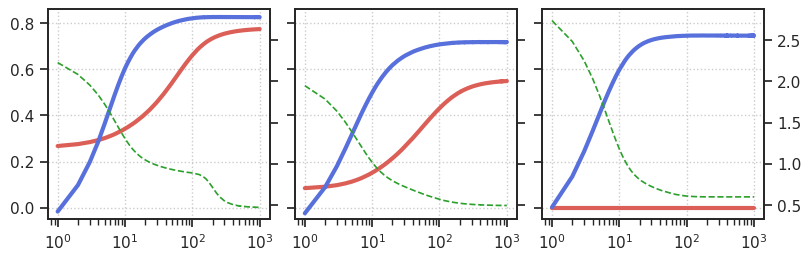

'/home/hadi/Dropbox/git/jb-progress-2025/figs/figs_2025-03/cnvrg/cnvrg_vH16_t-16.pdf'

In [9]:
fig = fig_convergence(df_convergence)
save_fig(f'cnvrg_{dataset}_t-{seq_len}.pdf', figs_dir, fig)

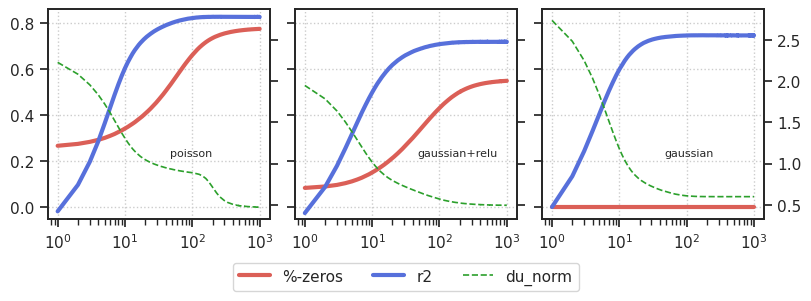

In [10]:
_ = fig_convergence(df_convergence, legend=True, display=True)

## MNIST

TODO: 

This one is a grid plot of 4 x 3 where we systematiclly sweep over values of seq_len x dataset: (16, 32, 64, 128) x (vH16, MNIST, ?)

In [8]:
device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

In [9]:
dataset = 'MNIST'
seq_len = 128
beta = 128
key = f'<grad|lin>-{dataset}-t-{seq_len}_b-{beta:0.3g}'
print(key)

<grad|lin>-MNIST-t-128_b-128

In [10]:
chkpts_dir = add_home('Dropbox/chkpts/_IterativeVAE')
fits = [f for f in os.listdir(chkpts_dir) if 'MNIST' in f]

fits = {
    'poisson': next(f for f in fits if 'poisson-<grad|lin>-MNIST-t-128_b-128' in f)
    'gaussian+relu': next(f for f in fits if 'gaussian+relu-<grad|lin>-MNIST-t-128_b-128' in f)
}



fits = sorted(fits, key=alphanum_sort_key)

print(fits)

[
    'gaussian+relu-<grad|lin>-MNIST-t-128_b-128_k-512_yoru-0_(2025_03_18,19:58)',
    'gaussian-<grad|lin>-MNIST-t-128_b-128_k-512_yoru-0_(2025_03_18,18:09)',
    'poisson-<grad|lin>-MNIST-t-128_b-128_k-512_chewie-2_(2025_03_23,19:44)',
    'poisson-<grad|lin>-MNIST-t-128_b-128_k-512_chewie-3_(2025_03_23,20:13)',
    'poisson-<grad|lin>-MNIST-t-128_b-128_k-512_mach-0_(2025_03_18,03:53)',
    'poisson-<grad|lin>-MNIST-t-128_b-128_k-512_mach-0_(2025_03_20,22:26)',
    'poisson-<grad|lin>-MNIST-t-128_b-128_k-512_mach-4_(2025_03_24,02:45)',
    'poisson-<grad|lin>-MNIST-t-128_b-128_k-512_yoru-1_(2025_03_24,04:18)'
]

In [11]:
tr = load_model_lite(pjoin(chkpts_dir, fits[-1]), device=device)[0]

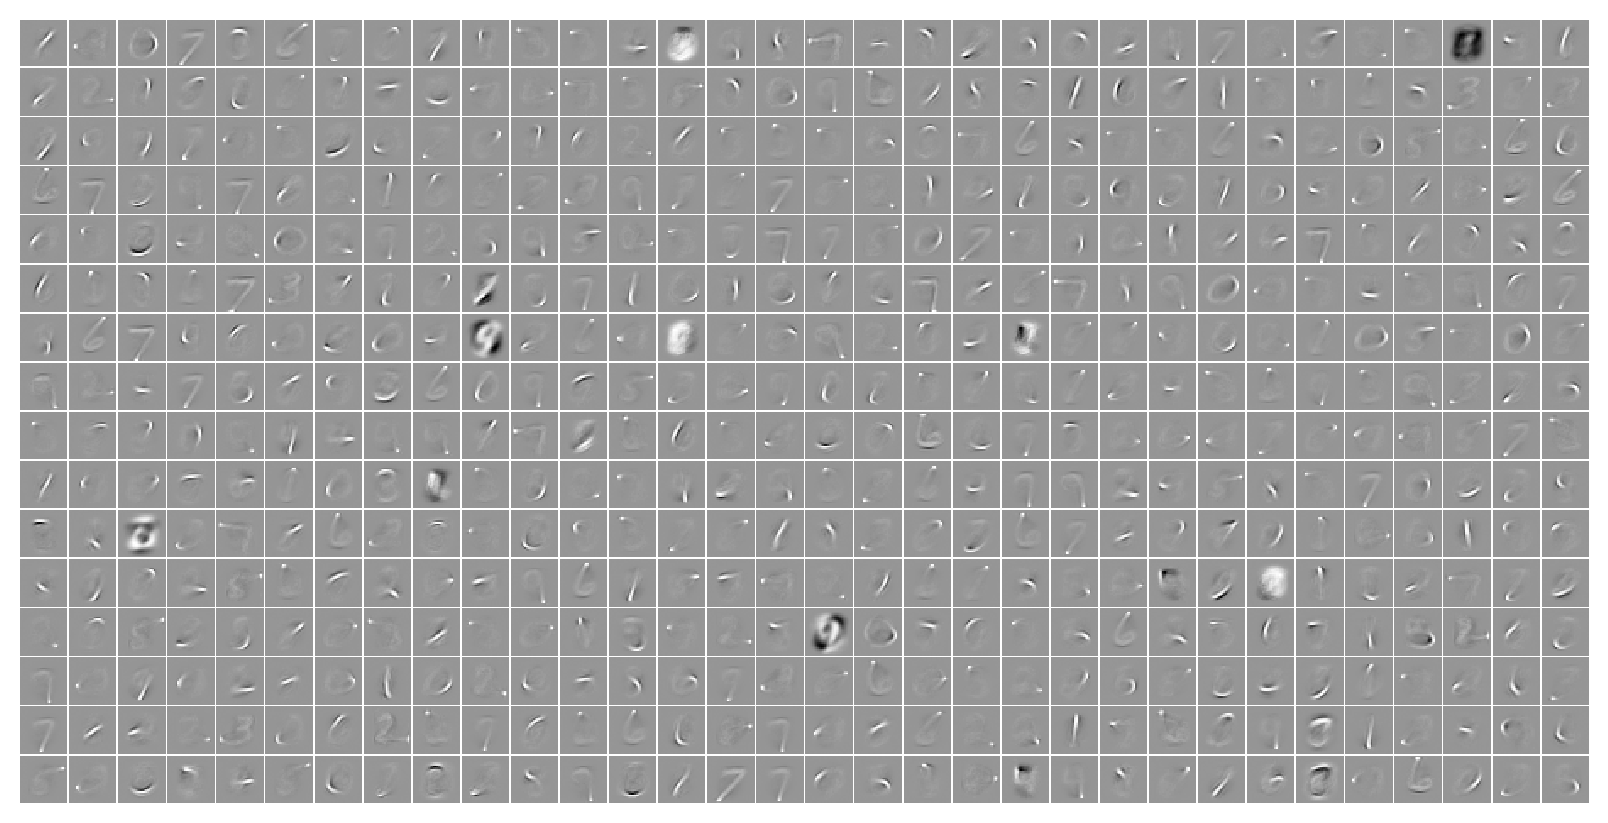

In [12]:
tr.model.show(method='abs-max');

In [24]:
seq_tot = 1000

df_convergence = collections.defaultdict(list)
for f in fits[:3]:
    tr = load_model_lite(pjoin(chkpts_dir, f), device=device)[0]
    output = tr.analysis(seq_total=seq_tot, data_batch_sz=200, n_data_batches=2)
    df_convergence['str_model'].extend([tr.model.cfg.str_model] * seq_tot)
    df_convergence['time'].extend(range(seq_tot))
    for k in ['r2', '%-zeros', 'du_norm']:
        df_convergence[k].extend(output[k])

df_convergence = pd.DataFrame(df_convergence)
df_convergence.shape

100%|███████████████████████████████████| 2/2 [00:05<00:00,  3.00s/it]


(3000, 5)

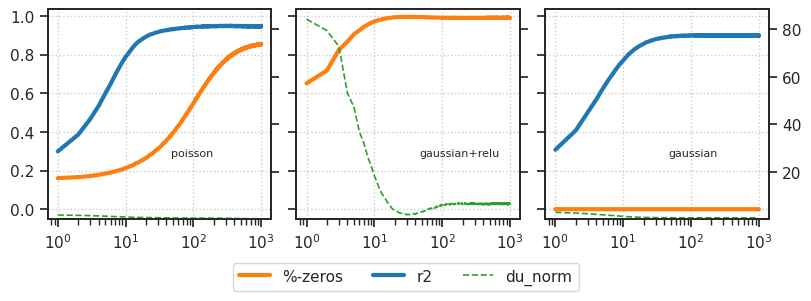

In [25]:
from figures.final import fig_convergence

_ = fig_convergence(df_convergence, legend=True, display=True)